In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
#import sys
#!{sys.executable} -m pip install scipy statsmodels pingouin
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

# 데이터 로드
df_merge = pd.read_csv("../../data/merged_df.csv")

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [ ]:
df_merge

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,age_group
0,78afa995795e4d85b5d9ceeca43f5fef,received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,1,F,75.0,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3,56+
1,a03223e636434f42ac4c3df47e8bac43,received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,1,Unknown,NaN,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN,1,1,5.0,20.0,10.0,1.0,1.0,0.0,0.0,discount_1,NaN
2,e2127556f4f64592b11af22de27a7932,received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,1,M,68.0,e2127556f4f64592b11af22de27a7932,2018-04-26,70000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,56+
3,8ec6ce2a7e7949b1bf142def7d0e0586,received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,1,Unknown,NaN,8ec6ce2a7e7949b1bf142def7d0e0586,2017-09-25,NaN,1,1,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3,NaN
4,68617ca6246f4fbc85e91a2a49552598,received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,1,Unknown,NaN,68617ca6246f4fbc85e91a2a49552598,2017-10-02,NaN,1,1,10.0,10.0,5.0,1.0,1.0,1.0,1.0,bogo_2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306132,b3a1272bc9904337b331bf348c3e8c17,transaction,714,NaN,1.59,NaN,30,M,66.0,b3a1272bc9904337b331bf348c3e8c17,2018-01-01,47000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56+
306133,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,NaN,9.53,NaN,30,M,52.0,68213b08d99a4ae1b0dcb72aebd9aa35,2018-04-08,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51-55
306134,a00058cf10334a308c68e7631c529907,transaction,714,NaN,3.61,NaN,30,F,63.0,a00058cf10334a308c68e7631c529907,2013-09-22,52000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56+
306135,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,NaN,3.53,NaN,30,M,57.0,76ddbd6576844afe811f1a3c0fbb5bec,2016-07-09,40000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56+


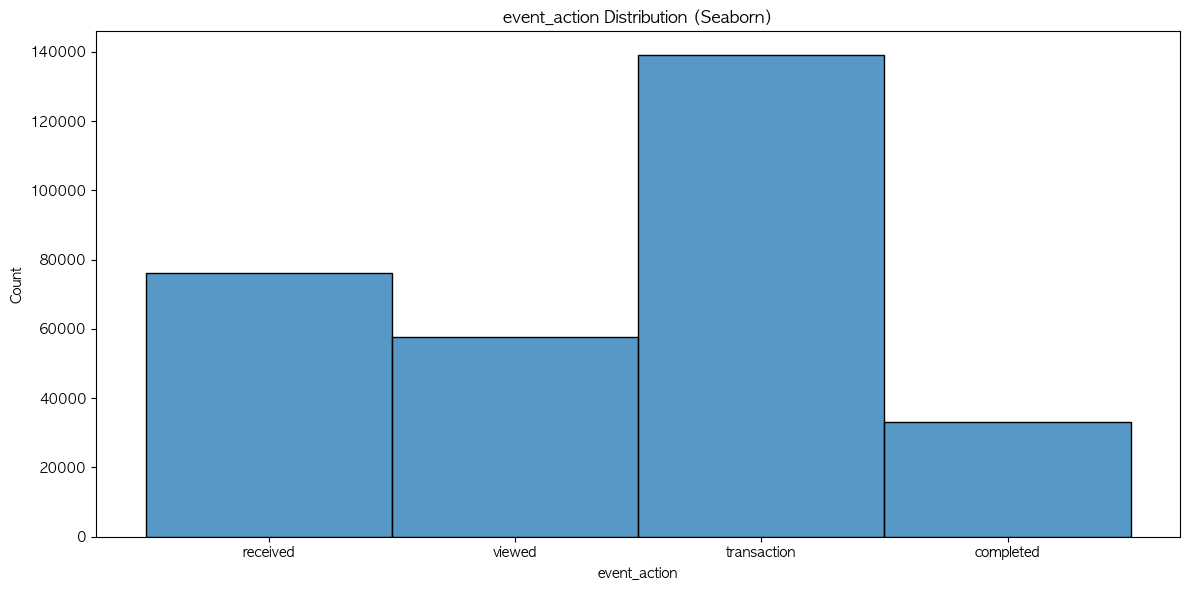

In [3]:
# 이벤트 타입별 분포 히스토그램
sns.histplot(data=df_merge, x="event", bins=5)
plt.title("event_action Distribution (Seaborn)")
plt.xlabel("event_action")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

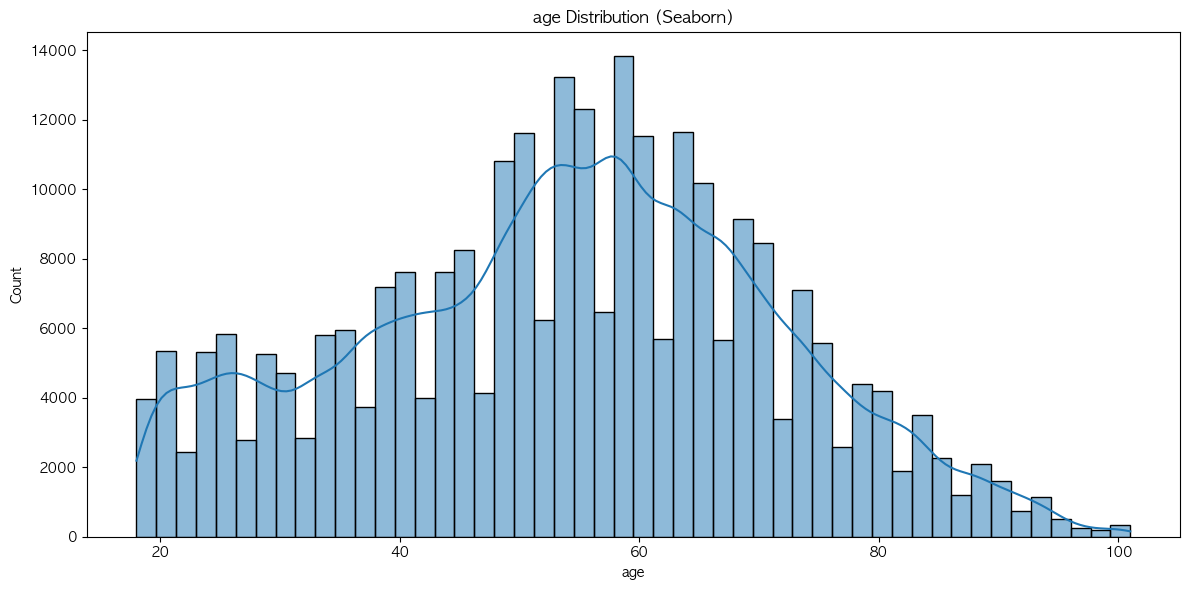

In [4]:
# 연령별 분포 히스토그램
sns.histplot(data=df_merge, x="age", bins=50, kde=True)
plt.title("age Distribution (Seaborn)")
plt.xlabel("age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
df_merge['age'].value_counts().sort_index()

age
18.0     1364
19.0     2593
20.0     2580
21.0     2759
22.0     2429
23.0     2560
24.0     2748
25.0     2766
26.0     3061
27.0     2796
28.0     2784
29.0     2465
30.0     2639
31.0     2062
32.0     2854
33.0     2748
34.0     3054
35.0     2535
36.0     3402
37.0     3723
38.0     3464
39.0     3715
40.0     3937
41.0     3672
42.0     3990
43.0     4040
44.0     3578
45.0     4268
46.0     3990
47.0     4146
48.0     5150
49.0     5652
50.0     5062
51.0     6550
52.0     6236
53.0     6679
54.0     6536
55.0     6373
56.0     5941
57.0     6461
58.0     7535
59.0     6296
60.0     6008
61.0     5530
62.0     5685
63.0     6079
64.0     5569
65.0     5043
66.0     5122
67.0     5663
68.0     4700
69.0     4453
70.0     4387
71.0     4049
72.0     3374
73.0     3731
74.0     3378
75.0     2787
76.0     2787
77.0     2568
78.0     2420
79.0     1968
80.0     2117
81.0     2066
82.0     1882
83.0     1989
84.0     1507
85.0     1286
86.0      974
87.0     1210
88.0     1125
89

In [6]:
# 연령 그룹화
df_merge['age_group'] = pd.cut(
    df_merge['age'],
    bins=[0,20,25,30,35,40,45,50,55,np.inf],
    labels=['0-20','21-25','26-30','31-35','36-40','41-45','46-50','51-55','56+']
)

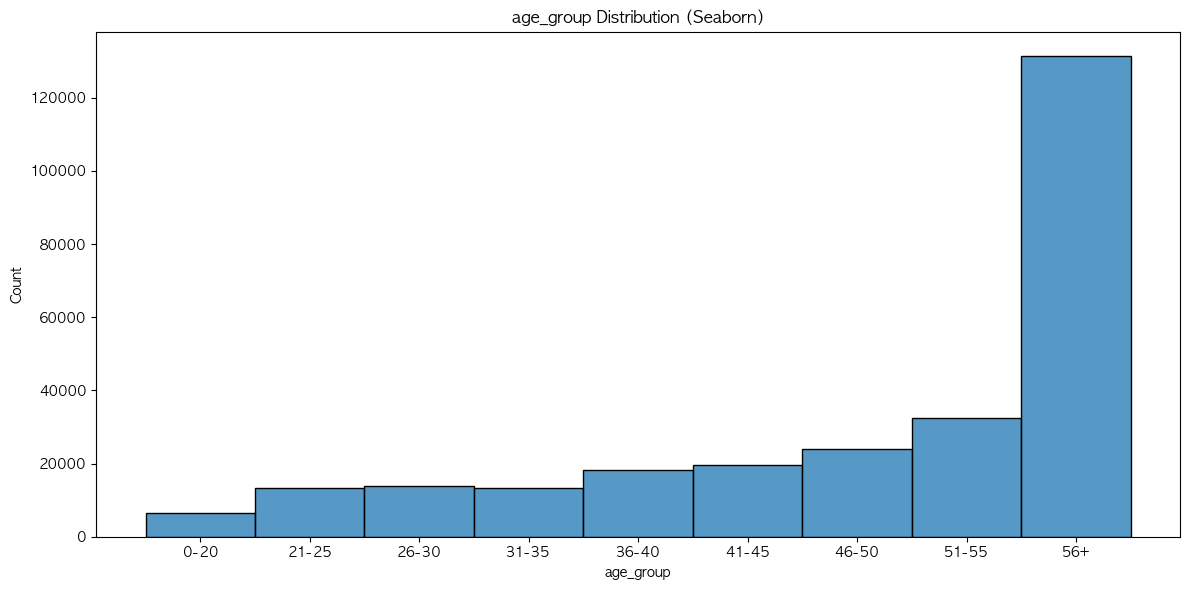

In [7]:
# 연령 그룹별 분포 히스토그램
sns.histplot(data=df_merge, x="age_group", bins=50)
plt.title("age_group Distribution (Seaborn)")
plt.xlabel("age_group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

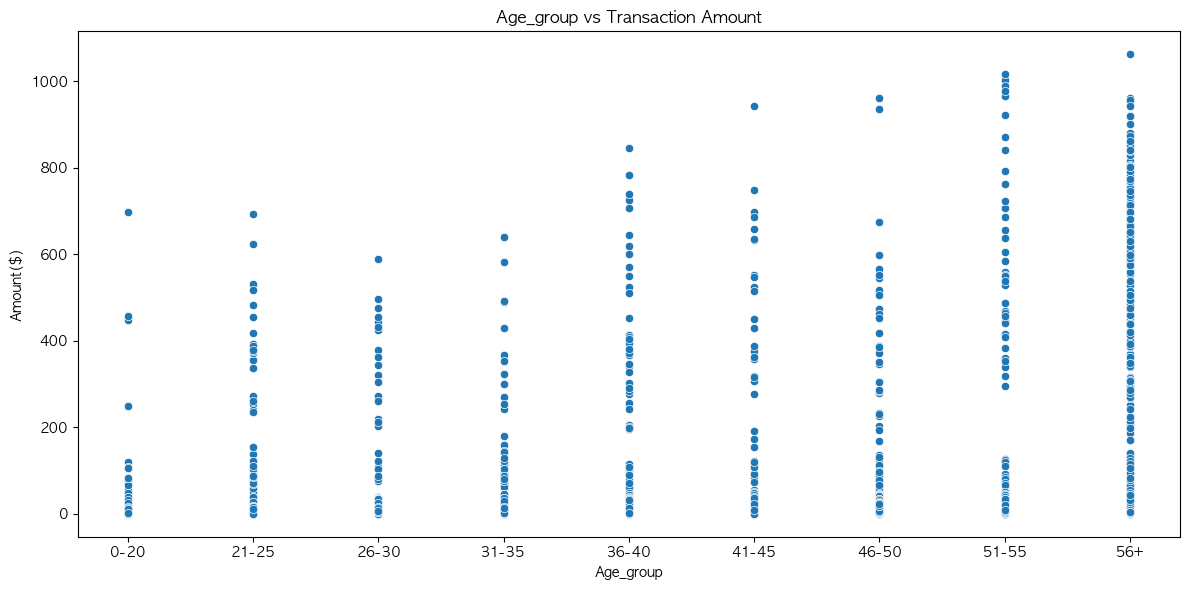

In [8]:
# 연령별 거래 금액 산점도
sns.scatterplot(data=df_merge, x="age_group", y="amount")
plt.title("Age_group vs Transaction Amount")
plt.xlabel("Age_group")
plt.ylabel("Amount($)")
plt.tight_layout()
plt.show()

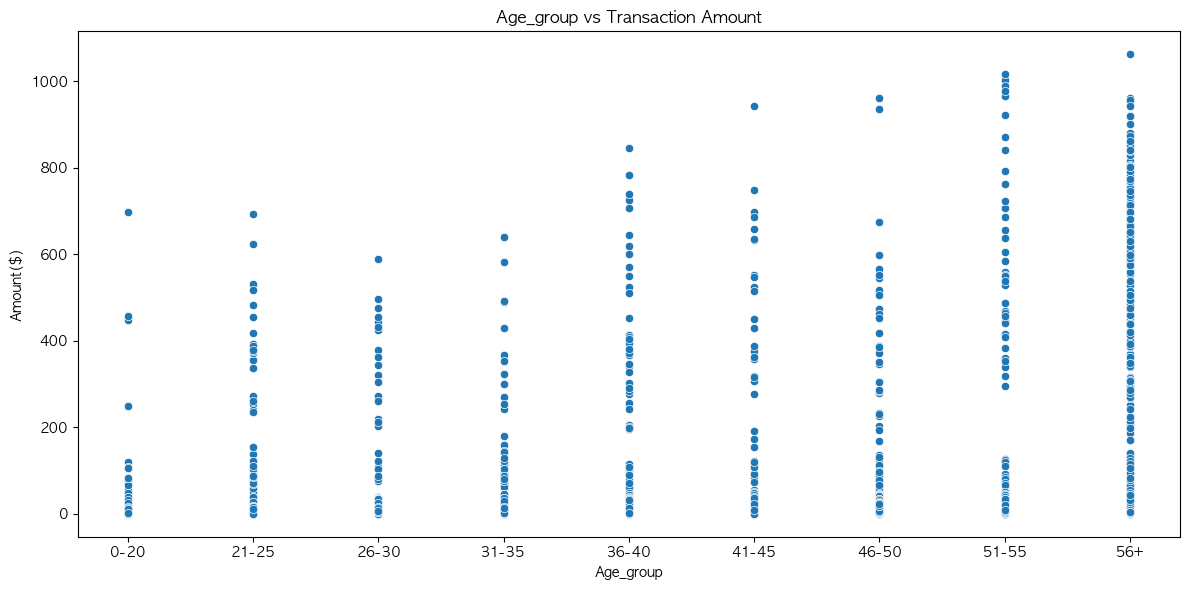

In [9]:
# 연령 그룹별 거래 금액 산점도
sns.scatterplot(data=df_merge, x="age_group", y="amount")
plt.title("Age_group vs Transaction Amount")
plt.xlabel("Age_group")
plt.ylabel("Amount($)")
plt.tight_layout()
plt.show()

In [12]:
df_merge['event'].value_counts()

event
transaction    138953
received        76277
viewed          57725
completed       33182
Name: count, dtype: int64

In [17]:
completed_event = df_merge[df_merge['event'] == 'completed']
completed_event

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,age_group
12658,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,completed,0,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,1,M,42.0,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,2016-01-17,96000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,41-45
12672,fe97aa22dd3e48c8b143116a8403dd52,completed,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,1,F,39.0,fe97aa22dd3e48c8b143116a8403dd52,2017-12-17,67000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3,36-40
12679,629fc02d56414d91bca360decdfa9288,completed,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.0,1,M,52.0,629fc02d56414d91bca360decdfa9288,2018-06-05,72000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3,51-55
12692,676506bad68e4161b9bbaffeb039626b,completed,0,ae264e3637204a6fb9bb56bc8210ddfd,NaN,10.0,1,M,37.0,676506bad68e4161b9bbaffeb039626b,2017-05-15,92000.0,0,0,10.0,10.0,7.0,0.0,1.0,1.0,1.0,bogo_1,36-40
12697,8f7dd3b2afe14c078eb4f6e6fe4ba97d,completed,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,10.0,1,M,48.0,8f7dd3b2afe14c078eb4f6e6fe4ba97d,2015-09-03,62000.0,0,0,10.0,10.0,5.0,1.0,1.0,1.0,1.0,bogo_2,46-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306078,0c027f5f34dd4b9eba0a25785c611273,completed,714,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,3.0,30,M,56.0,0c027f5f34dd4b9eba0a25785c611273,2017-10-24,61000.0,0,0,3.0,7.0,7.0,1.0,1.0,1.0,1.0,discount_2,56+
306100,a6f84f4e976f44508c358cc9aba6d2b3,completed,714,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,3.0,30,Unknown,NaN,a6f84f4e976f44508c358cc9aba6d2b3,2017-01-16,NaN,1,1,3.0,7.0,7.0,1.0,1.0,1.0,1.0,discount_2,NaN
306109,b895c57e8cd047a8872ce02aa54759d6,completed,714,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,30,Unknown,NaN,b895c57e8cd047a8872ce02aa54759d6,2017-01-25,NaN,1,1,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3,NaN
306112,8431c16f8e1d440880db371a68f82dd0,completed,714,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,30,M,39.0,8431c16f8e1d440880db371a68f82dd0,2018-06-27,39000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3,36-40


In [ ]:
# Complete 이벤트만 사용

channels = ['web', 'email', 'mobile', 'social']

avg_time = {}

for ch in channels:
    channel_df = completed_event[completed_event[ch] == 1]
    
    total_time = channel_df['time'].sum()
    total_count = len(channel_df)
    
    avg_time[ch] = total_time / total_count if total_count > 0 else 0

avg_time_df = pd.DataFrame(list(avg_time.items()), columns=['channel', 'avg_time'])

print(avg_time_df)

  channel    avg_time
0     web  400.452026
1   email  399.641553
2  mobile  396.293345
3  social  392.196987


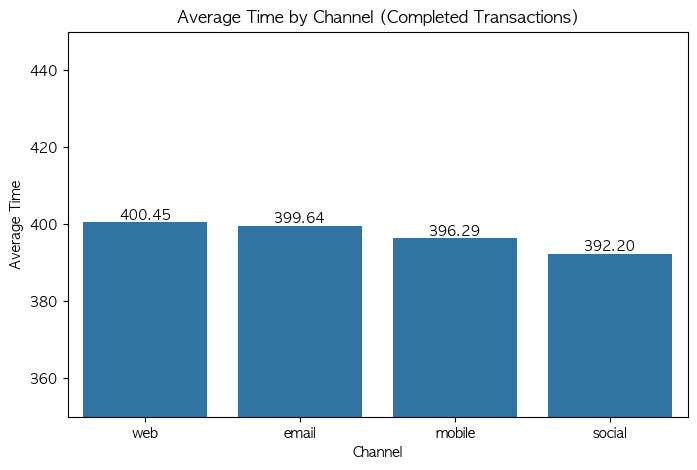

In [37]:
plt.figure(figsize=(8,5))

plt.xlabel('Channel')
plt.ylabel('Average Time')
plt.title('Average Time by Channel (Completed Transactions)')

ax = sns.barplot(data=avg_time_df, x='channel', y='avg_time')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

# y축 범위 설정
ax.set_ylim(350, 450)

plt.show()